<a href="https://colab.research.google.com/github/thiagomagela/CONFOA2019/blob/master/Final_Workshop_OA_Monitor_ConfOA2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Instalação de bibliotecas e configuração do ambiente

%pip install -q requests pandas matplotlib numpy

# Bibliotecas padrão do Python
import html
import json
import os
import re
import time
from dataclasses import dataclass
from datetime import datetime
from getpass import getpass
from pathlib import Path
from typing import Any, Callable, Iterable, Iterator
from urllib.parse import parse_qs, urlparse

# Bibliotecas externas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from matplotlib.ticker import PercentFormatter

# Configurações de exibição
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Ambiente pronto.")

Ambiente pronto.


---
## Credenciais da OpenAlex
Para obter sua chave da API, acesse (crie uma conta se ainda não tenha) o OpenAlex (https://openalex.org) e clique em Settings → API key para copiá-la. Depois, informe o seu e-email e a chave de API na célula a seguir abaixo. Você também pode salvar as suas credencias na função "Secrets" do colab:

# 2 — PARTE PRÁTICA

## Geração de indicadores com dados do OpenAlex

**Workshop — ConfOA 2026** · duração aproximada: 3h

Fabio Lorensi do Canto (UFSC/IBICT) · Thiago M. R. Dias (CEFET-MG/IBICT) · Marcel Garcia de Souza (IBICT) · Washington L. R. Carvalho Segundo (IBICT)

---

### Antes de começar

Faça uma cópia deste notebook:

1. Clique em **Arquivo**.
2. Selecione **Salvar uma cópia no Drive**.
3. Trabalhe sempre na sua própria cópia.

As credenciais do OpenAlex podem ser informadas manualmente ou armazenadas nos Secrets do Google Colab:
1. OPENALEX_EMAIL.
2. OPENALEX_API_KEY.



In [ ]:
# @title Informe seu e-mail e sua chave da API
from getpass import getpass

def ler_secret(nome):
    try:
        from google.colab import userdata
        return (userdata.get(nome) or "").strip() or None
    except Exception:
        return None

EMAIL = ler_secret("OPENALEX_EMAIL") or input(
    "Seu e-mail para o OpenAlex: "
).strip()

CHAVE_API = ler_secret("OPENALEX_API_KEY") or (
    getpass(
        "Sua OpenAlex API key "
        "(Enter para seguir sem chave): "
    ).strip() or None
)

print("E-mail:", "configurado" if EMAIL else "não informado")
print("Chave da API:", "informada" if CHAVE_API else "não informada")

E-mail: configurado
Chave da API: informada


In [ ]:
# @title Cliente de acesso à API OpenAlex
from dataclasses import dataclass
import time
import requests

BASE_URL = "https://api.openalex.org"
MAX_PER_PAGE = 100

@dataclass
class Credentials:
    email: str
    api_key: str | None = None

class OpenAlexError(RuntimeError):
    pass

class OpenAlexClient:
    def __init__(self, credentials):
        self.session = requests.Session()
        self.session.headers["User-Agent"] = f"OA_monitor/1.0 mailto:{credentials.email}"
        if credentials.api_key:
            self.session.headers["Authorization"] = f"Bearer {credentials.api_key}"
        self.last_rate_limit = {}

    def get(self, endpoint, params=None):
        url = f"{BASE_URL}/{endpoint.lstrip('/')}"
        for tentativa in range(5):
            try:
                r = self.session.get(url, params=params or {}, timeout=60)
            except requests.RequestException as erro:
                if tentativa == 4:
                    raise OpenAlexError(f"Falha de conexão: {erro}") from erro
            else:
                self.last_rate_limit = {
                    k: r.headers[k] for k in
                    ("X-RateLimit-Limit", "X-RateLimit-Remaining")
                    if k in r.headers
                }
                if r.status_code == 200:
                    return r.json()
                if r.status_code not in (429, 500, 502, 503, 504) or tentativa == 4:
                    raise OpenAlexError(f"Erro {r.status_code}: {r.text[:500]}")
            time.sleep(min(2 ** tentativa, 16))

    def count(self, endpoint, params=None):
        dados = self.get(endpoint, {**(params or {}), "per-page": 1})
        return int(dados.get("meta", {}).get("count", 0))

    def group_by(self, endpoint, campo, params=None):
        dados = self.get(endpoint, {
            **(params or {}), "group_by": campo, "per-page": MAX_PER_PAGE
        })
        return dados.get("group_by", [])

    def paginate(self, endpoint, params=None, max_records=None, on_progress=None):
        cursor, baixados, total = "*", 0, None
        while cursor:
            dados = self.get(endpoint, {
                **(params or {}), "per-page": MAX_PER_PAGE, "cursor": cursor
            })
            meta = dados.get("meta") or {}
            if total is None:
                total = int(meta.get("count", 0))
                if max_records is not None:
                    total = min(total, max_records)
            registros = dados.get("results") or []
            if not registros:
                break
            for registro in registros:
                yield registro
                baixados += 1
                if max_records is not None and baixados >= max_records:
                    if on_progress:
                        on_progress(baixados, total or baixados)
                    return
            if on_progress:
                on_progress(baixados, total or baixados)
            cursor = meta.get("next_cursor")

cliente = OpenAlexClient(Credentials(EMAIL, CHAVE_API))
print("Cliente OpenAlex preparado.")

Cliente OpenAlex preparado.


In [ ]:
# @title Funções de extração dos trabalhos
OA_STATUS_ORDEM = ["diamond", "hybrid", "gold", "green", "bronze", "closed", "unknown"]
OA_STATUS_ROTULO = dict(zip(
    OA_STATUS_ORDEM,
    ["Diamante", "Híbrido", "Dourado", "Verde", "Bronze", "Fechado", "Não informado"]
))
WORK_FIELDS = [
    "id", "doi", "title", "publication_year", "type", "cited_by_count",
    "fwci", "open_access", "apc_paid", "primary_location",
    "authorships", "primary_topic"
]
COLUNAS = [
    "id", "doi", "titulo", "ano", "tipo", "citacoes", "fwci", "is_oa",
    "oa_status", "oa_status_rotulo", "url_oa", "em_repositorio",
    "fonte", "fonte_id", "fonte_tipo", "fonte_editora",
    "fonte_no_doaj", "fonte_is_oa", "apc_pago_usd",
    "area", "domain", "instituicoes", "n_autores"
]

def ler_url_api(url):
    url = url.strip().replace("&amp;", "&").replace("\\&", "&")
    partes = urlparse(url)
    if (partes.scheme != "https" or partes.netloc.lower() != "api.openalex.org"
            or partes.path.rstrip("/") != "/works"):
        raise ValueError("Informe uma URL https://api.openalex.org/works?filter=...")
    parametros = {k: v[-1] for k, v in parse_qs(partes.query).items()}
    filtro = parametros.pop("filter", "")
    if not filtro:
        raise ValueError("A URL precisa conter o parâmetro filter.")
    for chave in ("page", "per_page", "per-page", "cursor", "select",
                  "mailto", "api_key", "group_by", "group-by"):
        parametros.pop(chave, None)
    return filtro, parametros

def extrair_trabalho(work):
    oa = work.get("open_access") or {}
    fonte = ((work.get("primary_location") or {}).get("source") or {})
    topico = work.get("primary_topic") or {}
    apc = work.get("apc_paid") or {}
    autorias = work.get("authorships") or []
    instituicoes = sorted({
        inst["display_name"]
        for autoria in autorias
        for inst in (autoria.get("institutions") or [])
        if inst.get("display_name")
    })
    status = oa.get("oa_status")
    if status not in OA_STATUS_ORDEM:
        status = "closed" if oa.get("is_oa") is False else "unknown"
    return {
        "id": work.get("id"), "doi": work.get("doi"),
        "titulo": work.get("title"), "ano": work.get("publication_year"),
        "tipo": work.get("type"), "citacoes": work.get("cited_by_count") or 0,
        "fwci": work.get("fwci"), "is_oa": bool(oa.get("is_oa")),
        "oa_status": status, "oa_status_rotulo": OA_STATUS_ROTULO[status],
        "url_oa": oa.get("oa_url"),
        "em_repositorio": bool(oa.get("any_repository_has_fulltext")),
        "fonte": fonte.get("display_name"), "fonte_id": fonte.get("id"),
        "fonte_tipo": fonte.get("type"),
        "fonte_editora": fonte.get("host_organization_name"),
        "fonte_no_doaj": bool(fonte.get("is_in_doaj")),
        "fonte_is_oa": bool(fonte.get("is_oa")),
        "apc_pago_usd": apc.get("value_usd"),
        "area": (topico.get("field") or {}).get("display_name"),
        "domain": (topico.get("domain") or {}).get("display_name"),
        "instituicoes": "; ".join(instituicoes),
        "n_autores": len(autorias)
    }

def extrair_works(client, filtro, max_registros=2000,
                  on_progress=None, parametros_adicionais=None):
    params = {
        **(parametros_adicionais or {}),
        "filter": filtro,
        "select": ",".join(WORK_FIELDS)
    }
    linhas = [
        extrair_trabalho(w)
        for w in client.paginate(
            "works", params, max_records=max_registros,
            on_progress=on_progress
        )
    ]
    df = pd.DataFrame(linhas, columns=COLUNAS)
    if not df.empty:
        df["ano"] = pd.to_numeric(df["ano"], errors="coerce").astype("Int64")
        for coluna in ("citacoes", "fwci", "apc_pago_usd"):
            df[coluna] = pd.to_numeric(df[coluna], errors="coerce")
    return df

print("Funções de extração preparadas.")

Funções de extração preparadas.


In [ ]:
# @title Indicadores
def _vazio(df):
    return df is None or len(df) == 0
def indicadores_gerais(df):
    if _vazio(df):
        return {}
    n = len(df)
    com_apc = df["apc_pago_usd"].notna() & (df["apc_pago_usd"] > 0)
    return {
        "trabalhos": n,
        "periodo": f"{int(df['ano'].min())}–{int(df['ano'].max())}",
        "trabalhos_oa": int(df["is_oa"].sum()),
        "taxa_oa": round(100 * df["is_oa"].sum() / n, 1),
        "taxa_diamante": round(100 * (df["oa_status"] == "diamond").sum() / n, 1),
        "taxa_em_repositorio": round(100 * df["em_repositorio"].sum() / n, 1),
        "taxa_no_doaj": round(100 * df["fonte_no_doaj"].sum() / n, 1),
        "taxa_fonte_aberta": round(100 * df["fonte_is_oa"].sum() / n, 1),
        "trabalhos_com_apc_pago": int(com_apc.sum()),
        "apc_total_usd": round(float(df.loc[com_apc, "apc_pago_usd"].sum()), 2),
        "apc_medio_usd": round(float(df.loc[com_apc, "apc_pago_usd"].mean()), 2) if com_apc.any() else 0.0,
        "citacoes_totais": int(df["citacoes"].sum()),
        "citacoes_por_trabalho": round(float(df["citacoes"].mean()), 2)
    }
def distribuicao_oa(df):
    colunas = ["oa_status", "rotulo", "trabalhos", "percentual"]
    if _vazio(df):
        return pd.DataFrame(columns=colunas)
    cont = df["oa_status"].value_counts()
    return pd.DataFrame([{"oa_status": s, "rotulo": OA_STATUS_ROTULO[s], "trabalhos": int(cont.get(s, 0)), "percentual": round(100 * int(cont.get(s, 0)) / len(df), 2)} for s in OA_STATUS_ORDEM])
def serie_anual_oa(df):
    colunas = ["ano", "trabalhos", "trabalhos_oa", "taxa_oa", "trabalhos_fonte_aberta", "taxa_fonte_aberta"]
    if _vazio(df):
        return pd.DataFrame(columns=colunas)
    g = df.groupby("ano", dropna=True).agg(trabalhos=("id", "size"), trabalhos_oa=("is_oa", "sum"), trabalhos_fonte_aberta=("fonte_is_oa", "sum")).reset_index()
    g["taxa_oa"] = (100 * g["trabalhos_oa"] / g["trabalhos"]).round(2)
    g["taxa_fonte_aberta"] = (100 * g["trabalhos_fonte_aberta"] / g["trabalhos"]).round(2)
    g["ano"] = g["ano"].astype(int)
    return g.sort_values("ano").reset_index(drop=True)
def serie_anual_por_status(df, percentual=True):
    colunas = ["ano", "oa_status", "rotulo", "trabalhos", "percentual", "ordem"]
    if _vazio(df):
        return pd.DataFrame(columns=colunas)
    g = df.groupby(["ano", "oa_status"], dropna=True).size().reset_index(name="trabalhos")
    total = g.groupby("ano")["trabalhos"].transform("sum")
    g["percentual"] = (100 * g["trabalhos"] / total).round(2)
    g["rotulo"] = g["oa_status"].map(OA_STATUS_ROTULO)
    g["ano"] = g["ano"].astype(int)
    g["ordem"] = g["oa_status"].map({s: i for i, s in enumerate(OA_STATUS_ORDEM)})
    return g.sort_values(["ano", "ordem"]).reset_index(drop=True)
def indicadores_apc(df):
    colunas = ["ano", "trabalhos", "trabalhos_com_apc", "cobertura", "apc_total_usd", "apc_medio_usd"]
    if _vazio(df):
        return pd.DataFrame(columns=colunas)
    d = df.copy()
    d["tem_apc"] = d["apc_pago_usd"].notna() & (d["apc_pago_usd"] > 0)
    g = d.groupby("ano", dropna=True).agg(trabalhos=("id", "size"), trabalhos_com_apc=("tem_apc", "sum"), apc_total_usd=("apc_pago_usd", "sum"), apc_medio_usd=("apc_pago_usd", "mean")).reset_index()
    g["cobertura"] = (100 * g["trabalhos_com_apc"] / g["trabalhos"]).round(2)
    g["apc_total_usd"] = g["apc_total_usd"].fillna(0).round(2)
    g["apc_medio_usd"] = g["apc_medio_usd"].fillna(0).round(2)
    return g[colunas]
def apc_por_editora(df, top=10):
    colunas = ["editora", "trabalhos_com_apc", "apc_total_usd", "apc_medio_usd"]
    if _vazio(df):
        return pd.DataFrame(columns=colunas)
    d = df[df["apc_pago_usd"].notna() & (df["apc_pago_usd"] > 0)].copy()
    if d.empty:
        return pd.DataFrame(columns=colunas)
    d["editora"] = d["fonte_editora"].fillna("(não informado)")
    g = d.groupby("editora").agg(trabalhos_com_apc=("id", "size"), apc_total_usd=("apc_pago_usd", "sum"), apc_medio_usd=("apc_pago_usd", "mean")).reset_index()
    g[["apc_total_usd", "apc_medio_usd"]] = g[["apc_total_usd", "apc_medio_usd"]].round(2)
    return g.sort_values("apc_total_usd", ascending=False).head(top).reset_index(drop=True)
def citacoes_por_status(df):
    colunas = ["oa_status", "rotulo", "trabalhos", "citacoes_media", "citacoes_mediana", "fwci_mediana"]
    if _vazio(df):
        return pd.DataFrame(columns=colunas)
    g = df.groupby("oa_status").agg(trabalhos=("id", "size"), citacoes_media=("citacoes", "mean"), citacoes_mediana=("citacoes", "median"), fwci_mediana=("fwci", "median")).reset_index()
    g["rotulo"] = g["oa_status"].map(OA_STATUS_ROTULO)
    g["_ordem"] = g["oa_status"].map({s: i for i, s in enumerate(OA_STATUS_ORDEM)})
    g = g.sort_values("_ordem").drop(columns="_ordem")
    g[["citacoes_media", "citacoes_mediana", "fwci_mediana"]] = g[["citacoes_media", "citacoes_mediana", "fwci_mediana"]].round(2)
    return g[colunas].reset_index(drop=True)
def top_fontes(df, top=15):
    colunas = ["fonte", "editora", "trabalhos", "taxa_oa", "no_doaj"]
    if _vazio(df):
        return pd.DataFrame(columns=colunas)
    d = df[(df["fonte_tipo"] == "journal") & df["fonte"].notna()]
    if d.empty:
        return pd.DataFrame(columns=colunas)
    g = d.groupby("fonte").agg(editora=("fonte_editora", "first"), trabalhos=("id", "size"), taxa_oa=("is_oa", "mean"), no_doaj=("fonte_no_doaj", "first")).reset_index()
    g["taxa_oa"] = (100 * g["taxa_oa"]).round(1)
    return g.sort_values("trabalhos", ascending=False).head(top).reset_index(drop=True)
def oa_por_area(df, minimo=10):
    if _vazio(df) or df["area"].isna().all():
        return pd.DataFrame(columns=["area", "trabalhos", "taxa_oa"])
    g = df.dropna(subset=["area"]).groupby("area").agg(trabalhos=("id", "size"), taxa_oa=("is_oa", "mean")).reset_index()
    g["taxa_oa"] = (100 * g["taxa_oa"]).round(1)
    return g[g["trabalhos"] >= minimo].sort_values("taxa_oa", ascending=False).reset_index(drop=True)
def oa_por_dominio(df):
    colunas = ["domain", "trabalhos", "trabalhos_oa", "taxa_oa"]
    if _vazio(df) or "domain" not in df.columns:
        return pd.DataFrame(columns=colunas)
    d = df.copy()
    d["domain"] = d["domain"].fillna("Não informado").replace("", "Não informado")
    g = d.groupby("domain", dropna=False).agg(trabalhos=("id", "size"), trabalhos_oa=("is_oa", "sum")).reset_index()
    g["taxa_oa"] = (100 * g["trabalhos_oa"] / g["trabalhos"]).round(1)
    return g.sort_values(["trabalhos", "domain"], ascending=[False, True]).reset_index(drop=True)
def painel_completo(df):
    return {
        "gerais": indicadores_gerais(df),
        "distribuicao_oa": distribuicao_oa(df),
        "serie_anual_oa": serie_anual_oa(df),
        "serie_anual_status": serie_anual_por_status(df),
        "apc_anual": indicadores_apc(df),
        "apc_editora": apc_por_editora(df),
        "citacoes_status": citacoes_por_status(df),
        "top_fontes": top_fontes(df),
        "oa_area": oa_por_area(df),
        "oa_domain": oa_por_dominio(df)
    }
print("Indicadores preparados.")

Indicadores preparados.


In [ ]:
# @title URL da consulta institucional
import requests

URL_EXEMPLO = (
    "https://api.openalex.org/works?"
    "filter=authorships.institutions.lineage:i1283613182,"
    "primary_location.source.type:journal,"
    "publication_year:2021-2025,type:article"
    "&per_page=1"
)

URL_API = input(
    "Cole outra URL ou pressione Enter para usar o exemplo: "
).strip() or URL_EXEMPLO

filtro, parametros_adicionais = ler_url_api(URL_API)

# Consulta à API
resposta = requests.get(URL_API)
resposta.raise_for_status()
dados = resposta.json()

# Total de registros encontrados
total_registros = dados["meta"]["count"]

print("Consulta:", URL_API)
print("Filtro aplicado:", filtro)

if parametros_adicionais:
    print("Parâmetros adicionais:", parametros_adicionais)

print(f"\nQuantidade de registros encontrados: {total_registros:,}")

Cole outra URL ou pressione Enter para usar o exemplo: https://api.openalex.org/works?filter=authorships.institutions.lineage:i40034438,primary_location.source.type:journal,publication_year:2021-2025,type:article&corpus=all&per_page=10&page=1
Consulta: https://api.openalex.org/works?filter=authorships.institutions.lineage:i40034438,primary_location.source.type:journal,publication_year:2021-2025,type:article&corpus=all&per_page=10&page=1
Filtro aplicado: authorships.institutions.lineage:i40034438,primary_location.source.type:journal,publication_year:2021-2025,type:article
Parâmetros adicionais: {'corpus': 'all'}

Quantidade de registros encontrados: 21,246


In [ ]:
# @title Resumir a consulta e baixar os dados
MAX_REGISTROS = 22000  # @param {type:"integer"}
parametros = {**parametros_adicionais, "filter": filtro}

total = cliente.count("works", parametros)
grupos = cliente.group_by("works", "open_access.oa_status", parametros)
print(f"Total no recorte: {total:,}".replace(",", "."))
for grupo in sorted(grupos, key=lambda g: g["count"], reverse=True):
    status, n = grupo["key"], int(grupo["count"])
    rotulo = OA_STATUS_ROTULO.get(status, status or "Não informado")
    print(f"{rotulo:<16} {n:>8,}  {100*n/max(total, 1):5.1f}%".replace(",", "."))

def progresso(baixados, previsto):
    print(f"\rBaixados: {baixados:,} / {previsto:,}".replace(",", "."), end="")

inicio = time.time()
df = extrair_works(
    cliente, filtro, max_registros=MAX_REGISTROS,
    on_progress=progresso,
    parametros_adicionais=parametros_adicionais
)
print(f"\nConcluído: {len(df):,} trabalhos em {time.time()-inicio:.0f}s".replace(",", "."))
if len(df) < total:
    print("Os indicadores seguintes descrevem os trabalhos baixados, não o recorte completo.")
display(df.head(3))

Total no recorte: 21.246
Diamante           12.978   61.1%
Fechado             2.856   13.4%
Dourado             2.571   12.1%
Híbrido             1.411    6.6%
Bronze                906    4.3%
Verde                 524    2.5%
Baixados: 21.246 / 21.246
Concluído: 21.246 trabalhos em 105s


,id,doi,titulo,ano,tipo,citacoes,fwci,is_oa,oa_status,oa_status_rotulo,url_oa,em_repositorio,fonte,fonte_id,fonte_tipo,fonte_editora,fonte_no_doaj,fonte_is_oa,apc_pago_usd,area,domain,instituicoes,n_autores
0,https://openalex.org/W3177498683,https://doi.org/10.1038/s41586-021-03629-6,Amazonia as a carbon source linked to deforest...,2021,article,1101,76.7686,True,green,Verde,https://research.wur.nl/en/publications/amazon...,True,Nature,https://openalex.org/S137773608,journal,Nature Portfolio,False,False,NaN,Environmental Science,Physical Sciences,Centro Nacional de Monitoramento e Alertas de ...,19
1,https://openalex.org/W3110283336,https://doi.org/10.36660/abc.20201238,Diretrizes Brasileiras de Hipertensão Arterial...,2021,article,1076,122.2087,True,diamond,Diamante,https://abccardiol.org/wp-content/uploads/arti...,True,Arquivos Brasileiros de Cardiologia,https://openalex.org/S67004851,journal,Sociedade Brasileira de Cardiologia (SBC),True,True,NaN,Medicine,Health Sciences,Centro Universitário Cesmac; Clinics Hospital ...,97
2,https://openalex.org/W4386209525,https://doi.org/10.1002/art.42624,The 2023 ACR / EULAR Antiphospholipid Syndrome...,2023,article,484,86.5672,True,green,Verde,https://hdl.handle.net/2027.42/178218,True,Arthritis & Rheumatology,https://openalex.org/S4210186158,journal,Wiley,False,False,NaN,Medicine,Health Sciences,Addenbrooke's Hospital; Assistance Publique – ...,66


In [ ]:
# @title Funções para os gráficos
CORES_OA = {"diamond": "#2a78d6", "hybrid": "#e87ba4", "gold": "#eda100", "green": "#1baf7a", "bronze": "#eb6834", "closed": "#8f8e88"}
CORES_OA["unknown"] = "#b7b7b7"
AZUL = "#2a78d6"
GRADE = "#e4e3df"
TINTA_PRIMARIA = "#0b0b0b"
TINTA_SECUNDARIA = "#52514e"
def _estilo(ax, titulo, subtitulo=""):
    ax.set_title(titulo, loc="left", fontsize=13, color=TINTA_PRIMARIA, pad=26 if subtitulo else 10)
    if subtitulo:
        ax.text(0, 1.012, subtitulo, transform=ax.transAxes, fontsize=9.5, color=TINTA_SECUNDARIA, va="bottom")
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color(GRADE)
    ax.tick_params(colors=TINTA_SECUNDARIA, labelsize=9, length=0)
    ax.grid(axis="y", color=GRADE, linewidth=0.8)
    ax.set_axisbelow(True)
def grafico_distribuicao_oa(dist):
    d = dist[dist["trabalhos"] > 0].iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.55 * max(len(d), 3) + 1.6))
    ax.barh(d["rotulo"], d["percentual"], color=[CORES_OA[s] for s in d["oa_status"]], height=0.62)
    for y, (pct, n) in enumerate(zip(d["percentual"], d["trabalhos"])):
        ax.text(pct + max(d["percentual"]) * 0.015, y, f"{pct:.1f}% ({n:,})".replace(",", "."), va="center", fontsize=9, color=TINTA_SECUNDARIA)
    ax.set_xlabel("% dos trabalhos")
    _estilo(ax, "Distribuição por via de acesso", f"{int(d['trabalhos'].sum()):,} trabalhos".replace(",", "."))
    fig.tight_layout()
    return fig
def grafico_serie_oa(serie):
    fig, ax = plt.subplots(figsize=(9, 4.4))
    ax.plot(serie["ano"], serie["taxa_oa"], color=AZUL, linewidth=2, marker="o", label="Taxa de acesso aberto")
    if "taxa_fonte_aberta" in serie.columns:
        ax.plot(serie["ano"], serie["taxa_fonte_aberta"], color="#1baf7a", linewidth=2, marker="o", label="Trabalhos em fontes abertas")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Ano")
    ax.set_ylabel("% dos trabalhos")
    ax.legend(frameon=False)
    _estilo(ax, "Taxa de acesso aberto por ano", "% dos trabalhos do ano")
    fig.tight_layout()
    return fig
def grafico_composicao_anual(longo):
    piv = longo.pivot_table(index="ano", columns="oa_status", values="percentual", aggfunc="sum").fillna(0)
    piv = piv.reindex(columns=[s for s in OA_STATUS_ORDEM if s in piv.columns])
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    base = pd.Series(0.0, index=piv.index)
    for status in piv.columns:
        ax.bar(piv.index, piv[status], bottom=base, color=CORES_OA[status], label=OA_STATUS_ROTULO[status], edgecolor="white")
        base += piv[status]
    ax.set_ylim(0, 100)
    ax.set_ylabel("% dos trabalhos")
    ax.set_xlabel("Ano")
    ax.legend(frameon=False, ncol=3)
    _estilo(ax, "Composição das vias por ano", "% dos trabalhos de cada ano")
    fig.tight_layout()
    return fig
def grafico_apc(apc):
    fig, ax = plt.subplots(figsize=(9, 4.4))
    ax.bar(apc["ano"], apc["apc_total_usd"], width=0.62, color=AZUL)
    ax.set_ylabel("APC pago (USD)")
    _estilo(ax, "APCs pagos por ano", "Valor identificado pelo OpenAlex — estimativa")
    fig.tight_layout()
    return fig
def grafico_citacoes(cit):
    d = cit[cit["trabalhos"] > 0]
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.bar(d["rotulo"], d["citacoes_mediana"], color=[CORES_OA[s] for s in d["oa_status"]])
    ax.set_ylabel("Citações medianas")
    _estilo(ax, "Citações por via de acesso (mediana)", "Associação, não causa")
    fig.tight_layout()
    return fig
def grafico_oa_por_area(area):
    d = area.sort_values("taxa_oa").tail(12)
    fig, ax = plt.subplots(figsize=(8.5, 0.42 * max(len(d), 4) + 1.6))
    ax.barh(d["area"], d["taxa_oa"], color=AZUL)
    ax.set_xlabel("% de acesso aberto")
    _estilo(ax, "Taxa de acesso aberto por área")
    fig.tight_layout()
    return fig
print("Funções de gráficos preparadas.")

Funções de gráficos preparadas.


In [ ]:
# @title Visualização das tabelas de indicadores
from IPython.display import display
if "df" not in globals() or df.empty:
    raise RuntimeError("Execute primeiro a célula 'Baixar os dados' para criar o DataFrame df.")
painel = painel_completo(df)
print("1. Indicadores gerais")
display(pd.DataFrame([painel["gerais"]]))
print("2. Distribuição por via de acesso")
display(painel["distribuicao_oa"])
print("3. Série anual de acesso aberto")
display(painel["serie_anual_oa"])
print("4. Composição das vias de acesso por ano")
display(painel["serie_anual_status"])
print("5. APCs pagos por ano")
display(painel["apc_anual"])
print("6. APCs por editora")
display(painel["apc_editora"])
print("7. Citações por via de acesso")
display(painel["citacoes_status"])
print("8. Periódicos mais utilizados")
display(painel["top_fontes"])
print("9. Acesso aberto por área")
display(painel["oa_area"])
print("10. Acesso aberto por domínio")
display(painel["oa_domain"])

1. Indicadores gerais


,trabalhos,periodo,trabalhos_oa,taxa_oa,taxa_diamante,taxa_em_repositorio,taxa_no_doaj,taxa_fonte_aberta,trabalhos_com_apc_pago,apc_total_usd,apc_medio_usd,citacoes_totais,citacoes_por_trabalho
0,10093,2021–2025,7708,76.4,47.6,38.8,33.6,63.1,1830,3565821.0,1948.54,58171,5.76


2. Distribuição por via de acesso


,oa_status,rotulo,trabalhos,percentual
0,diamond,Diamante,4805,47.61
1,hybrid,Híbrido,592,5.87
2,gold,Dourado,1550,15.36
3,green,Verde,415,4.11
4,bronze,Bronze,346,3.43
5,closed,Fechado,2385,23.63
6,unknown,Não informado,0,0.00


3. Série anual de acesso aberto


...

,fonte,editora,trabalhos,taxa_oa,no_doaj
0,Research Society and Development,Grupo de Pesquisa Metodologias em Ensino e Apr...,126,100.0,False
1,Brazilian Journal of Development,Brazilian Journal of Development,115,100.0,False
2,Caderno Pedagógico,Editora Univates,82,100.0,False
3,OBSERVATÓRIO DE LA ECONOMÍA LATINOAMERICANA,Servicios Academicos Intercontinentales,70,100.0,False
4,Contribuciones a las Ciencias Sociales,Servicios Academicos Intercontinentales,69,100.0,False
5,IEEE Access,Institute of Electrical and Electronics Engineers,68,100.0,True
6,Revista Brasileira de Educação Ambiental (RevBEA),Universidade Federal de São Paulo,68,100.0,False
7,XXVI Seminário de Iniciação Científica e Tecno...,None,60,0.0,False
8,Revista de Gestão Social e Ambiental,Centro Universitario da FEI,56,100.0,False
9,Seminário Internacional sobre Desenvolvimento ...,Universidade de Santa Cruz do Sul,48,100.0,False


9. Acesso aberto por área


,area,trabalhos,taxa_oa
0,Arts and Humanities,398,99.2
1,Social Sciences,1711,97.1
2,Psychology,189,94.2
3,Neuroscience,41,90.2
4,"Economics, Econometrics and Finance",88,86.4
5,"Business, Management and Accounting",280,86.1
6,Health Professions,149,83.2
7,Decision Sciences,162,81.5
8,Mathematics,330,80.9
9,"Pharmacology, Toxicology and Pharmaceutics",25,80.0


10. Acesso aberto por domínio


,domain,trabalhos,trabalhos_oa,taxa_oa
0,Physical Sciences,5011,3362,67.1
1,Social Sciences,2828,2684,94.9
2,Life Sciences,1492,1091,73.1
3,Health Sciences,754,564,74.8
4,Não informado,8,7,87.5


In [ ]:
# @title Acesso aberto por ano: colaboração e financiamento
ANOS = range(2020, 2025)

def contagem_anual(filtro_extra="", somente_aa=False):
    criterios = filtro + (f",{filtro_extra}" if filtro_extra else "")
    if somente_aa:
        criterios += ",open_access.is_oa:true"
    grupos = cliente.group_by(
        "works", "publication_year",
        {**parametros_adicionais, "filter": criterios}
    )
    return {int(g["key"]): int(g["count"]) for g in grupos}

recortes = {
    "todos": "",
    "br": "authorships.countries:BR,countries_distinct_count:1",
    "internacional": "authorships.countries:BR,countries_distinct_count:>1",
    "financiador": "funders.id:!null"
}
contagens = {
    nome: (contagem_anual(criterio), contagem_anual(criterio, True))
    for nome, criterio in recortes.items()
}

def celula(n, n_aa):
    return f"{100*n_aa/n:.1f}% (n={n:,})".replace(",", ".") if n else "—"

linhas = []
for ano in ANOS:
    total, total_aa = (d.get(ano, 0) for d in contagens["todos"])
    br, br_aa = (d.get(ano, 0) for d in contagens["br"])
    inter, inter_aa = (d.get(ano, 0) for d in contagens["internacional"])
    com, com_aa = (d.get(ano, 0) for d in contagens["financiador"])
    linhas.append({
        "Ano": ano,
        "Somente BR": celula(br, br_aa),
        "Colaboração internacional": celula(inter, inter_aa),
        "Sem financiador identificado": celula(total-com, total_aa-com_aa),
        "Com financiador identificado": celula(com, com_aa)
    })

tabela_comparativa = pd.DataFrame(linhas).set_index("Ano")
display(tabela_comparativa)

,Somente BR,Colaboração internacional,Sem financiador identificado,Com financiador identificado
Ano,,,,
2020,—,—,—,—
2021,71.4% (n=1.827),68.3% (n=394),75.3% (n=1.452),62.5% (n=769)
2022,77.5% (n=1.482),73.6% (n=397),80.2% (n=1.177),70.8% (n=702)
2023,79.2% (n=1.577),72.3% (n=383),83.1% (n=1.255),68.5% (n=705)
2024,79.6% (n=1.674),69.9% (n=355),84.5% (n=1.384),63.9% (n=645)


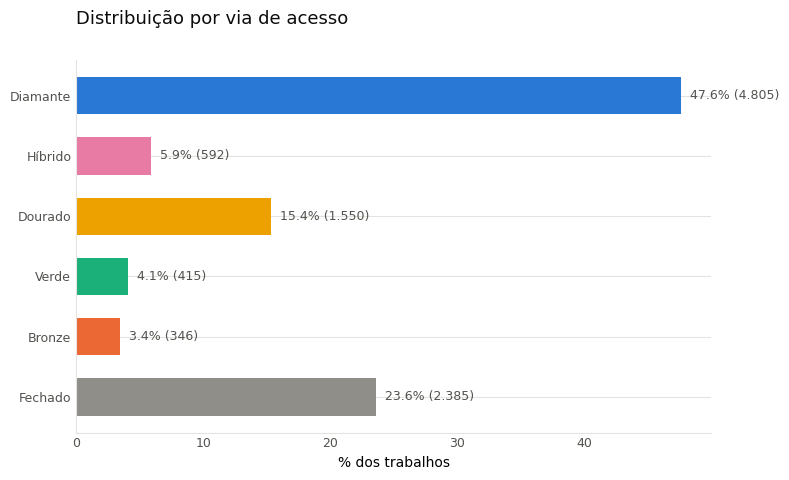

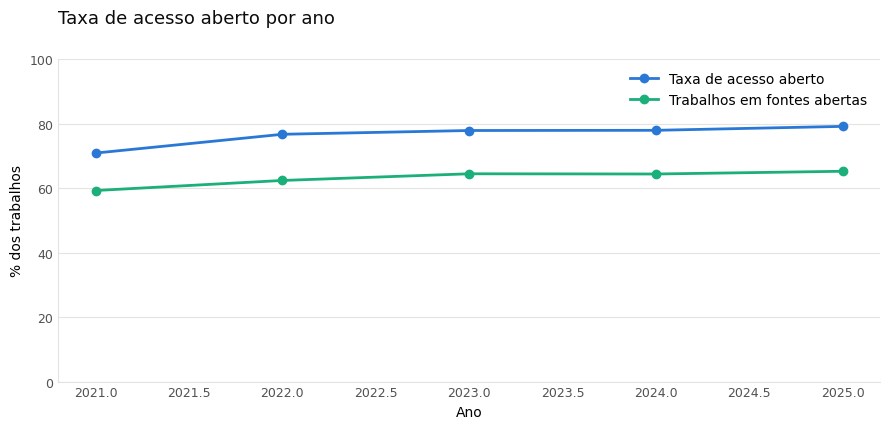

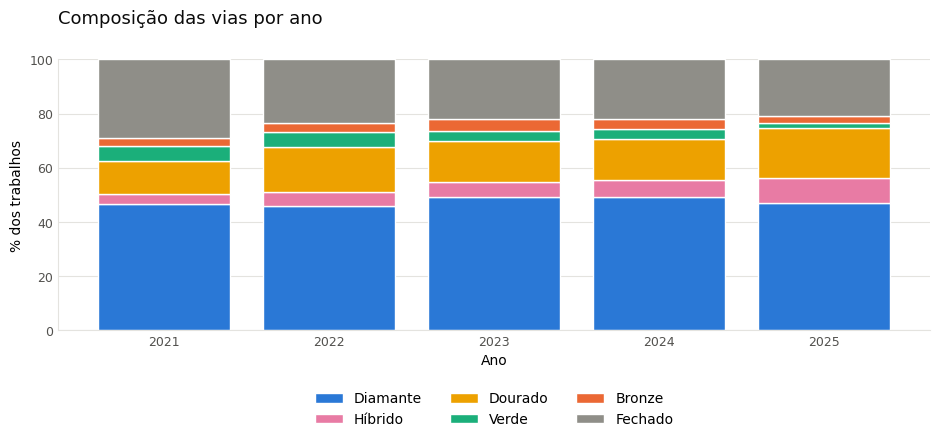

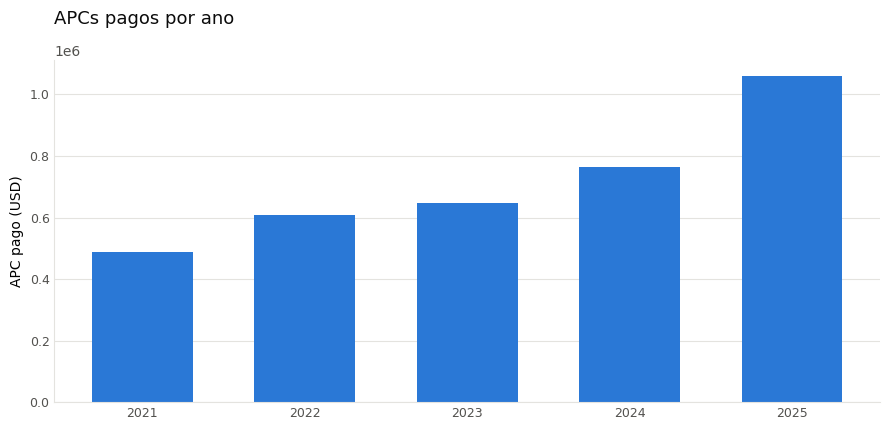

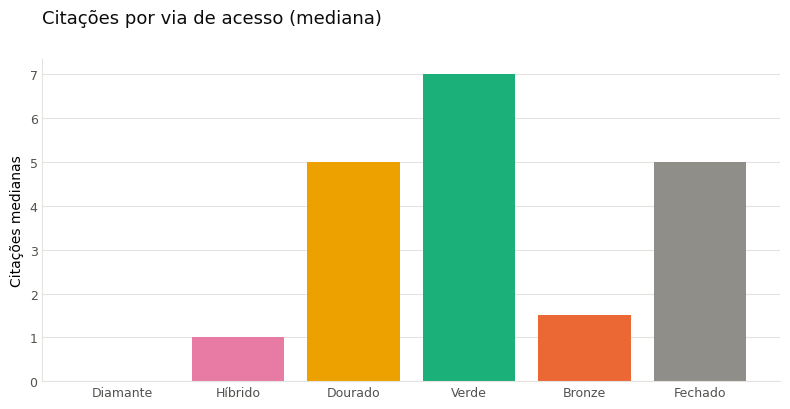

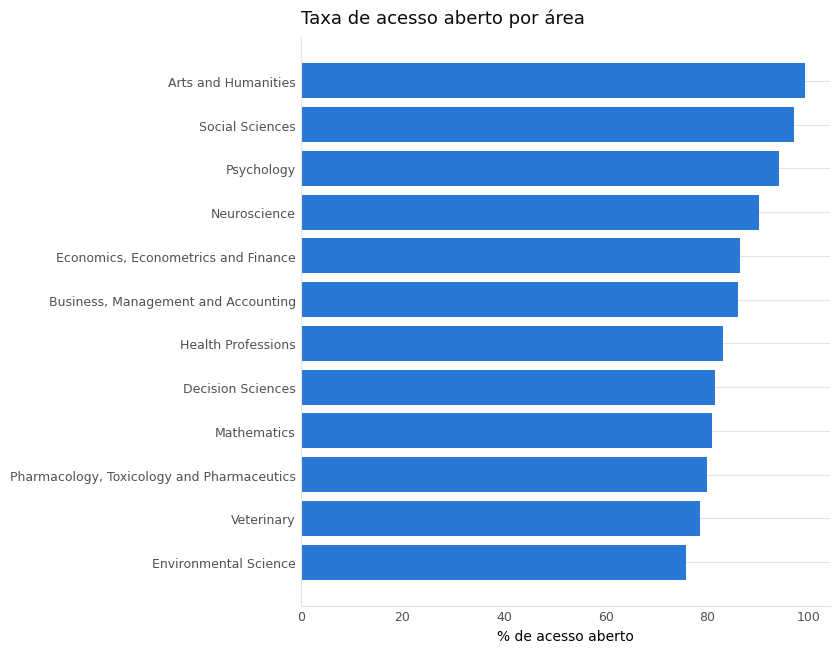

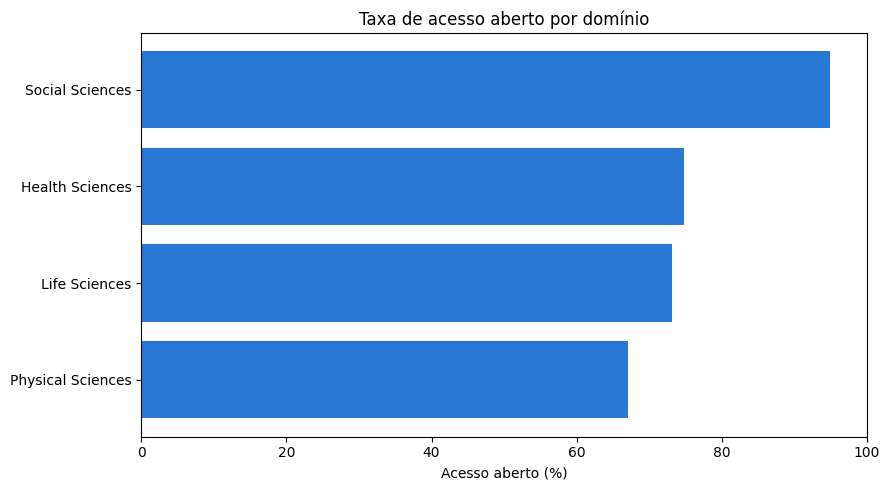

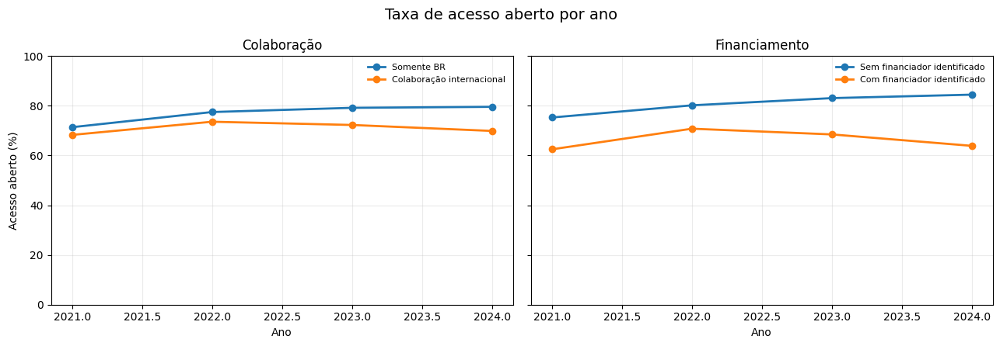

In [ ]:
# @title Gráficos dos indicadores
graficos = [
    (grafico_distribuicao_oa, "distribuicao_oa"),
    (grafico_serie_oa, "serie_anual_oa"),
    (grafico_composicao_anual, "serie_anual_status"),
    (grafico_apc, "apc_anual"),
    (grafico_citacoes, "citacoes_status"),
    (grafico_oa_por_area, "oa_area"),
]

for funcao, chave in graficos:
    tabela = painel[chave]
    if tabela.empty or ("trabalhos" in tabela and tabela["trabalhos"].sum() == 0):
        continue
    fig = funcao(tabela)
    if chave == "serie_anual_status":
        fig.axes[0].legend(
            loc="upper center", bbox_to_anchor=(0.5, -0.18),
            ncol=3, frameon=False
        )
        fig.subplots_adjust(bottom=0.30)
    for ax in fig.axes:
        for texto in list(ax.texts):
            if texto.get_position() == (0, 1.012) and texto.get_transform() == ax.transAxes:
                texto.remove()
    display(fig)
    plt.close(fig)

dominios = (
    painel["oa_domain"]
    .query("trabalhos >= 10")
    .nlargest(10, "trabalhos")
    .sort_values("taxa_oa")
)
if not dominios.empty:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(dominios["domain"], dominios["taxa_oa"], color=AZUL)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Acesso aberto (%)")
    ax.set_title("Taxa de acesso aberto por domínio")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

def taxa(coluna):
    return pd.to_numeric(
        tabela_comparativa[coluna].str.extract(r"^([\d.]+)%")[0],
        errors="coerce"
    )

fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
comparacoes = [
    (eixos[0], "Colaboração",
     ["Somente BR", "Colaboração internacional"]),
    (eixos[1], "Financiamento",
     ["Sem financiador identificado", "Com financiador identificado"]),
]
for ax, titulo, colunas in comparacoes:
    for coluna in colunas:
        ax.plot(
            tabela_comparativa.index, taxa(coluna),
            marker="o", linewidth=2, label=coluna
        )
    ax.set_title(titulo)
    ax.set_xlabel("Ano")
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

eixos[0].set_ylabel("Acesso aberto (%)")
fig.suptitle("Taxa de acesso aberto por ano", fontsize=14)
fig.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
# @title Gerar o dashboard completo
%pip install -q plotly
import plotly.express as px
import plotly.io as pio
from pathlib import Path
from google.colab import files

if "painel" not in globals() or "tabela_comparativa" not in globals():
    raise RuntimeError("Execute primeiro as células 11 e 12.")

cards = []
def incluir(titulo, fig, tabela=None, largo=False):
    fig.update_layout(
        template="plotly_white", height=370,
        margin=dict(l=12, r=12, t=12, b=55),
        legend_title_text=""
    )
    cards.append((titulo, fig, tabela, largo))

d = painel["distribuicao_oa"].query("trabalhos > 0")
incluir("Distribuição por via de acesso",
    px.bar(d, x="percentual", y="rotulo", orientation="h",
           color="oa_status", color_discrete_map=CORES_OA,
           labels={"percentual": "Trabalhos (%)", "rotulo": ""})
      .update_layout(showlegend=False), d)

d = painel["serie_anual_oa"]
incluir("Acesso aberto por ano",
    px.line(d, x="ano", y=["taxa_oa", "taxa_fonte_aberta"], markers=True,
            labels={"ano": "Ano", "value": "Trabalhos (%)"}), d)

d = painel["serie_anual_status"]
cores_rotulos = {OA_STATUS_ROTULO[k]: v for k, v in CORES_OA.items()}
incluir("Composição das vias por ano",
    px.bar(d, x="ano", y="percentual", color="rotulo", barmode="stack",
           color_discrete_map=cores_rotulos,
           labels={"ano": "Ano", "percentual": "Trabalhos (%)"}), d)

d = painel["apc_anual"]
incluir("APCs identificados por ano",
    px.bar(d, x="ano", y="apc_total_usd",
           labels={"ano": "Ano", "apc_total_usd": "USD"}), d)

d = painel["citacoes_status"]
incluir("Mediana de citações por via",
    px.bar(d, x="rotulo", y="citacoes_mediana", color="oa_status",
           color_discrete_map=CORES_OA,
           labels={"rotulo": "Via", "citacoes_mediana": "Citações"})
      .update_layout(showlegend=False), d)

d = painel["oa_area"].sort_values("trabalhos", ascending=False).head(12)
if not d.empty:
    incluir("Acesso aberto por área",
        px.bar(d.sort_values("taxa_oa"), x="taxa_oa", y="area",
               orientation="h",
               labels={"taxa_oa": "Acesso aberto (%)", "area": ""}), d)

d = painel["oa_domain"].query("trabalhos >= 10").nlargest(10, "trabalhos")
if not d.empty:
    incluir("Acesso aberto por domínio",
        px.bar(d.sort_values("taxa_oa"), x="taxa_oa", y="domain",
               orientation="h",
               labels={"taxa_oa": "Acesso aberto (%)", "domain": ""}), d)

comparacao = tabela_comparativa.reset_index().copy()
for coluna in tabela_comparativa.columns:
    comparacao[coluna] = pd.to_numeric(
        comparacao[coluna].str.extract(r"^([\d.]+)%")[0],
        errors="coerce"
    )

for titulo, colunas in [
    ("Colaboração: acesso aberto por ano",
     ["Somente BR", "Colaboração internacional"]),
    ("Financiamento: acesso aberto por ano",
     ["Sem financiador identificado", "Com financiador identificado"])
]:
    fig = px.line(comparacao, x="Ano", y=colunas, markers=True,
                  labels={"value": "Acesso aberto (%)"})
    fig.update_yaxes(range=[0, 100])
    incluir(titulo, fig, tabela_comparativa.reset_index(), largo=True)

def tabela_html(tabela):
    return tabela.to_html(
        index=False, border=0, classes="dados", escape=True,
        na_rep="—", float_format=lambda x: f"{x:,.1f}"
    )

blocos = []
for i, (titulo, fig, tabela, largo) in enumerate(cards):
    grafico = pio.to_html(
        fig, full_html=False, include_plotlyjs=(i == 0),
        config={"displaylogo": False, "responsive": True}
    )
    dados = (
        f"<details><summary>Ver tabela</summary>{tabela_html(tabela)}</details>"
        if tabela is not None else ""
    )
    classe = "card largo" if largo else "card"
    blocos.append(
        f'<section class="{classe}"><h2>{html.escape(titulo)}</h2>'
        f"{grafico}{dados}</section>"
    )

for titulo, chave in [
    ("APCs por editora", "apc_editora"),
    ("Periódicos mais utilizados", "top_fontes")
]:
    blocos.append(
        f'<section class="card largo"><h2>{titulo}</h2>'
        f'{tabela_html(painel[chave])}</section>'
    )

g = painel["gerais"]
kpis = [
    ("Trabalhos analisados", f'{g["trabalhos"]:,}'),
    ("Acesso aberto", f'{g["taxa_oa"]:.1f}%'),
    ("Fonte aberta", f'{g["taxa_fonte_aberta"]:.1f}%'),
    ("Via diamante", f'{g["taxa_diamante"]:.1f}%'),
    ("APC identificado", f'US$ {g["apc_total_usd"]:,.0f}')
]
painel_kpis = "".join(
    f'<div class="kpi"><strong>{valor}</strong><span>{titulo}</span></div>'
    for titulo, valor in kpis
)
escopo = (
    f"{len(df):,} de {total:,} trabalhos do recorte"
    if "total" in globals() else f"{len(df):,} trabalhos"
)

css = """
body{font-family:system-ui;margin:0;background:#f5f7fb;color:#172b45}
.wrap{max-width:1350px;margin:auto;padding:28px}h1{margin:0}
header p{color:#64748b}.kpis{display:flex;flex-wrap:wrap;gap:12px;margin:22px 0}
.kpi,.card{background:white;box-shadow:0 2px 12px #1326410d;
border:1px solid #e3eaf2;border-radius:12px}
.kpi{padding:16px 22px;min-width:175px}
.kpi strong{display:block;font-size:25px}.kpi span{color:#64748b}
.grid{display:grid;grid-template-columns:repeat(2,minmax(0,1fr));gap:16px}
.card{padding:18px;min-width:0}.largo{grid-column:1/-1}
h2{font-size:18px;margin:0 0 10px}
.dados{border-collapse:collapse;width:100%;font-size:13px}
.dados th,.dados td{border-bottom:1px solid #e3eaf2;padding:8px;text-align:left}
details{overflow:auto}summary{cursor:pointer;color:#2563a6;margin:8px 0}
@media(max-width:850px){.grid{grid-template-columns:1fr}}
"""

conteudo = (
    '<!doctype html><html lang="pt-BR"><head><meta charset="utf-8">'
    '<meta name="viewport" content="width=device-width,initial-scale=1">'
    f'<title>Indicadores de Ciência Aberta</title><style>{css}</style>'
    '</head><body><div class="wrap"><header>'
    '<h1>Indicadores de Ciência Aberta</h1>'
    f'<p>{html.escape(escopo)} · {html.escape(str(g["periodo"]))}</p>'
    f'</header><div class="kpis">{painel_kpis}</div>'
    f'<main class="grid">{"".join(blocos)}</main></div></body></html>'
)

arquivo_dashboard = Path("dashboard_oa.html")
arquivo_dashboard.write_text(conteudo, encoding="utf-8")
print(f"Dashboard criado: {arquivo_dashboard}")
files.download(str(arquivo_dashboard))

# Exibir o dashboard na saída da célula
from IPython.display import HTML, display

display(HTML(
    f'<iframe srcdoc="{html.escape(conteudo, quote=True)}" '
    'style="width:100%;height:1200px;border:0;" '
    'title="Indicadores de Ciência Aberta"></iframe>'
))

Dashboard criado: dashboard_oa.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning:

Consider using IPython.display.IFrame instead



# ANÁLISE DA PRODUÇÃO DE PESQUISADOR
Ex: `https://api.openalex.org/works?filter=authorships.author.id:a5028281315,publication_year:2014-2018&corpus=all&per_page=10&page=1\$0$0`

In [ ]:
# @title Informe a URL da produção do pesquisador
URL_EXEMPLO_AUTOR = (
    "https://api.openalex.org/works?"
    "filter=authorships.author.id:A5028281315,"
    "publication_year:2014-2018&corpus=all"
)
URL_API_AUTOR = input(
    "Cole uma URL /works de um pesquisador ou pressione Enter para usar o exemplo: "
).strip() or URL_EXEMPLO_AUTOR

filtro_autor, parametros_autor = ler_url_api(URL_API_AUTOR)
identificacao = re.search(
    r"(?:^|,)authorships\.author\.(id|orcid):([^,]+)",
    filtro_autor
)
if not identificacao or "|" in identificacao.group(2):
    raise ValueError("A URL deve filtrar um único autor por ID OpenAlex ou ORCID.")

tipo_identificador = identificacao.group(1)
identificador_autor = identificacao.group(2)
print("Filtro do pesquisador:", filtro_autor)

Cole uma URL /works de um pesquisador ou pressione Enter para usar o exemplo: 
Filtro do pesquisador: authorships.author.id:A5028281315,publication_year:2014-2018


In [ ]:
# @title Baixar e analisar a produção do pesquisador
inicio_autor = time.time()
total_autor = cliente.count("works", {**parametros_autor, "filter": filtro_autor})
if total_autor == 0:
    raise ValueError("Nenhum trabalho encontrado para essa URL.")

df_autor = extrair_works(
    cliente, filtro_autor, max_registros=None,
    parametros_adicionais=parametros_autor
)
painel_autor = painel_completo(df_autor)

try:
    if tipo_identificador == "id":
        codigo = identificador_autor.rstrip("/").split("/")[-1]
        dados_autor = cliente.get(f"authors/{codigo}")
    else:
        resultado = cliente.get("authors", {
            "filter": f"orcid:{identificador_autor}", "per-page": 1
        })
        dados_autor = (resultado.get("results") or [{}])[0]
except OpenAlexError:
    dados_autor = {}

nome_autor = dados_autor.get("display_name") or identificador_autor
print(f"Pesquisador: {nome_autor}")
print(f"Trabalhos: {len(df_autor):,} de {total_autor:,}".replace(",", "."))
print(f"Indicadores preparados em {time.time() - inicio_autor:.0f}s")

Pesquisador: Susumu Kitagawa
Trabalhos: 383 de 383
Indicadores preparados em 1s


In [ ]:
# @title Dashboard da produção do pesquisador
import html as html_lib
import plotly.express as px
import plotly.io as pio
from IPython.display import HTML, display
from google.colab import files

graficos_autor = []
def adicionar_grafico(fig, titulo):
    fig.update_layout(title=titulo, template="plotly_white", height=360,
                      margin=dict(l=35, r=25, t=65, b=35), font=dict(size=12))
    graficos_autor.append(pio.to_html(
        fig, full_html=False, include_plotlyjs="inline" if not graficos_autor else False,
        config={"displaylogo": False}
    ))

d = painel_autor["distribuicao_oa"]
fig = px.bar(d, x="rotulo", y="trabalhos", color="oa_status",
             color_discrete_map=CORES_OA, labels={"rotulo": "", "trabalhos": "Trabalhos"})
fig.update_layout(showlegend=False)
adicionar_grafico(fig, "Distribuição por modalidade de acesso")

d = painel_autor["serie_anual_oa"]
fig = px.line(d, x="ano", y="taxa_oa", markers=True, hover_data=["trabalhos"],
              labels={"ano": "Ano", "taxa_oa": "Acesso aberto (%)"})
fig.update_yaxes(range=[0, 100])
adicionar_grafico(fig, "Taxa de acesso aberto por ano")

d = painel_autor["serie_anual_status"]
cores_rotulos = {OA_STATUS_ROTULO[s]: CORES_OA[s] for s in OA_STATUS_ORDEM}
fig = px.bar(d, x="ano", y="percentual", color="rotulo", barmode="stack",
             color_discrete_map=cores_rotulos,
             category_orders={"rotulo": [OA_STATUS_ROTULO[s] for s in OA_STATUS_ORDEM]},
             labels={"ano": "Ano", "percentual": "% dos trabalhos", "rotulo": "Modalidade"})
fig.update_xaxes(type="category")
adicionar_grafico(fig, "Modalidades de acesso por ano")

d = painel_autor["citacoes_status"]
fig = px.bar(d, x="rotulo", y="citacoes_media", color="oa_status",
             color_discrete_map=CORES_OA,
             labels={"rotulo": "", "citacoes_media": "Média de citações"})
fig.update_layout(showlegend=False)
adicionar_grafico(fig, "Média de citações por modalidade")

d = painel_autor["top_fontes"].head(10)
if not d.empty:
    fig = px.bar(d.sort_values("trabalhos"), x="trabalhos", y="fonte",
                 orientation="h", hover_data=["taxa_oa"],
                 labels={"fonte": "", "trabalhos": "Trabalhos", "taxa_oa": "AA (%)"})
    adicionar_grafico(fig, "Periódicos mais utilizados")

d = painel_autor["oa_area"]
if not d.empty:
    fig = px.bar(d.sort_values("taxa_oa"), x="taxa_oa", y="area",
                 orientation="h", hover_data=["trabalhos"],
                 labels={"area": "", "taxa_oa": "Acesso aberto (%)"})
    fig.update_xaxes(range=[0, 100])
    adicionar_grafico(fig, "Acesso aberto por área")

d = painel_autor["apc_anual"]
if not d.empty and d["apc_total_usd"].sum() > 0:
    fig = px.bar(d, x="ano", y="apc_total_usd",
                 labels={"ano": "Ano", "apc_total_usd": "APC registrado (US$)"})
    adicionar_grafico(fig, "APC registrado por ano")

g = painel_autor["gerais"]
metricas = [
    ("Trabalhos", f"{g['trabalhos']:,}"),
    ("Acesso aberto", f"{g['taxa_oa']:.1f}%"),
    ("Acesso diamante", f"{g['taxa_diamante']:.1f}%"),
    ("Em repositório", f"{g['taxa_em_repositorio']:.1f}%"),
    ("Citações", f"{g['citacoes_totais']:,}")
]
cartoes = "".join(
    f'<div class="metrica"><span>{rotulo}</span><strong>{valor}</strong></div>'
    for rotulo, valor in metricas
)
conteudo = f"""<!doctype html><html lang="pt-BR"><head><meta charset="utf-8">
<title>Indicadores de ciência aberta — {html_lib.escape(nome_autor)}</title>
<style>
body{{font-family:Arial,sans-serif;background:#f3f6fa;color:#17263c;margin:0}}
main{{max-width:1250px;margin:auto;padding:28px}}
h1{{margin:0 0 6px;font-size:28px}}p{{color:#526276}}
.metricas,.graficos{{display:grid;gap:16px}}
.metricas{{grid-template-columns:repeat(auto-fit,minmax(170px,1fr));margin:24px 0}}
.graficos{{grid-template-columns:repeat(auto-fit,minmax(500px,1fr))}}
.metrica,.grafico{{background:white;border-radius:12px;box-shadow:0 2px 10px #dbe3ed;padding:14px}}
.metrica span{{display:block;color:#526276;font-size:14px}}
.metrica strong{{display:block;margin-top:8px;font-size:28px;color:#2a78d6}}
.grafico{{overflow:hidden}}
@media(max-width:600px){{.graficos{{grid-template-columns:1fr}}}}
</style></head><body><main>
<h1>Indicadores de ciência aberta — {html_lib.escape(nome_autor)}</h1>
<p>Produção de {html_lib.escape(g['periodo'])} · {len(df_autor):,} trabalhos analisados</p>
<div class="metricas">{cartoes}</div>
<div class="graficos">{''.join(f'<div class="grafico">{grafico}</div>' for grafico in graficos_autor)}</div>
<p>Fonte: OpenAlex · Consulta: {html_lib.escape(URL_API_AUTOR)}</p>
</main></body></html>"""

arquivo_autor = "dashboard_autor.html"
with open(arquivo_autor, "w", encoding="utf-8") as arquivo:
    arquivo.write(conteudo)
display(HTML(f'<iframe srcdoc="{html_lib.escape(conteudo, quote=True)}" '
             'style="width:100%;height:950px;border:0" title="Dashboard do pesquisador"></iframe>'))
files.download(arquivo_autor)

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning:

Consider using IPython.display.IFrame instead



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Usando dados de geolocalização para gerar mapas
Ex: `https://api.openalex.org/institutions?filter=country_code:PT,type:education&per_page=10&page=1`

In [ ]:
# @title Localização das instituições
from urllib.parse import urlparse, parse_qs
import html
import folium

URL_EXEMPLO_INST = (
    "https://api.openalex.org/institutions?"
    "filter=country_code:PT,type:education&per_page=10&page=1"
)
url_inst = input(
    "Cole a URL de instituições ou pressione Enter para usar o exemplo: "
).strip() or URL_EXEMPLO_INST

partes = urlparse(url_inst)
if partes.netloc != "api.openalex.org" or partes.path.rstrip("/") != "/institutions":
    raise ValueError("Informe uma URL da API OpenAlex para /institutions.")
parametros_url = parse_qs(partes.query)
filtro_inst = parametros_url.get("filter", [""])[0]
if not filtro_inst:
    raise ValueError("A URL precisa conter um filtro.")

adicionais_inst = {
    chave: valores[-1] for chave, valores in parametros_url.items()
    if chave not in {"filter", "page", "per_page", "per-page",
                     "cursor", "select", "api_key", "mailto"}
}
instituicoes_pt = []
cursor = "*"
while cursor:
    resposta = cliente.get("institutions", {
        **adicionais_inst, "filter": filtro_inst,
        "per-page": 100, "cursor": cursor
    })
    lote = resposta.get("results") or []
    if not lote:
        break
    instituicoes_pt.extend(lote)
    novo_cursor = (resposta.get("meta") or {}).get("next_cursor")
    cursor = novo_cursor if novo_cursor != cursor else None

mapa_inst = folium.Map(location=[39.5, -8.0], zoom_start=6, tiles="OpenStreetMap")
pontos = []
for inst in instituicoes_pt:
    geo = inst.get("geo") or {}
    lat, lon = geo.get("latitude"), geo.get("longitude")
    if lat is None or lon is None:
        continue
    pontos.append([lat, lon])
    folium.CircleMarker(
        location=[lat, lon], radius=5, color="#2a78d6",
        fill=True, fill_opacity=0.8,
        tooltip=html.escape(inst.get("display_name") or "Instituição")
    ).add_to(mapa_inst)

if not pontos:
    raise ValueError("Nenhuma instituição do recorte possui coordenadas.")
mapa_inst.fit_bounds(pontos)
display(mapa_inst)

Cole a URL de instituições ou pressione Enter para usar o exemplo: 


In [ ]:
# @title Mapa de calor das instituições por produtividade (works_count)
import math
import folium
from folium.plugins import HeatMap
from IPython.display import display

if "instituicoes_pt" not in globals() or not instituicoes_pt:
    raise RuntimeError("Execute primeiro a célula de localização das instituições.")

dados_calor = []

for inst in instituicoes_pt:
    geo = inst.get("geo") or {}
    lat = geo.get("latitude")
    lon = geo.get("longitude")
    produtividade = inst.get("works_count")

    if lat is None or lon is None or produtividade is None:
        continue

    try:
        lat, lon = float(lat), float(lon)
        produtividade = float(produtividade)
    except (TypeError, ValueError):
        continue

    if (
        all(math.isfinite(v) for v in (lat, lon, produtividade))
        and -90 <= lat <= 90
        and -180 <= lon <= 180
        and produtividade > 0
    ):
        dados_calor.append([lat, lon, produtividade])

if not dados_calor:
    raise ValueError("Nenhuma instituição possui coordenadas e produtividade válidas.")

# Pesos proporcionais à produtividade, na escala de 0 a 1.
maior_producao = max(p[2] for p in dados_calor)
pesos = [
    [lat, lon, produtividade / maior_producao]
    for lat, lon, produtividade in dados_calor
]

mapa_calor = folium.Map(
    location=[dados_calor[0][0], dados_calor[0][1]],
    zoom_start=6,
    tiles="OpenStreetMap"
)

HeatMap(
    pesos,
    name="Produtividade das instituições",
    radius=30,
    blur=20,
    min_opacity=0.2,
    gradient={
        0.2: "blue",
        0.4: "cyan",
        0.6: "lime",
        0.8: "orange",
        1.0: "red"
    }
).add_to(mapa_calor)

mapa_calor.fit_bounds([[lat, lon] for lat, lon, _ in dados_calor])

print(f"Instituições representadas: {len(dados_calor):,}")
print("Peso: total acumulado de trabalhos por instituição (works_count).")
print("Cores quentes indicam maior concentração espacial de produção.")

display(mapa_calor)

Instituições representadas: 291
Peso: total acumulado de trabalhos por instituição (works_count).
Cores quentes indicam maior concentração espacial de produção.


In [ ]:
# @title Mapa de periódicos do DOAJ por país
%pip -q install pycountry
from urllib.parse import urlparse, parse_qs
import pycountry
import plotly.express as px

URL_EXEMPLO_DOAJ = (
    "https://api.openalex.org/sources?"
    "filter=is_oa:true,listed_in:doaj,type:journal&per_page=10&page=1"
)
url_doaj = input(
    "Cole a URL de periódicos ou pressione Enter para usar o exemplo: "
).strip() or URL_EXEMPLO_DOAJ

partes = urlparse(url_doaj)
if partes.netloc != "api.openalex.org" or partes.path.rstrip("/") != "/sources":
    raise ValueError("Informe uma URL da API OpenAlex para /sources.")
parametros_url = parse_qs(partes.query)
filtro_doaj = parametros_url.get("filter", [""])[0]
if not filtro_doaj:
    raise ValueError("A URL precisa conter um filtro.")

adicionais = {
    chave: valores[-1] for chave, valores in parametros_url.items()
    if chave not in {"filter", "page", "per_page", "per-page", "cursor",
                     "group_by", "group-by", "select", "sort", "api_key", "mailto"}
}
grupos, cursor, total_fontes = [], "*", None
while cursor:
    resposta = cliente.get("sources", {
        **adicionais, "filter": filtro_doaj,
        "group_by": "country_code:include_unknown",
        "per_page": 200, "cursor": cursor
    })
    if total_fontes is None:
        total_fontes = resposta["meta"]["count"]
    lote = resposta.get("group_by") or []
    if not lote:
        break
    grupos.extend(lote)
    proximo = resposta["meta"].get("next_cursor")
    cursor = proximo if proximo != cursor else None

linhas = []
for grupo in grupos:
    codigo = str(grupo["key"]).rsplit("/", 1)[-1].strip(")]").upper()
    pais = pycountry.countries.get(alpha_2=codigo)
    if pais:
        linhas.append({
            "pais": pais.name, "iso3": pais.alpha_3,
            "periodicos": grupo["count"]
        })
df_paises_doaj = pd.DataFrame(linhas)
if df_paises_doaj.empty:
    raise ValueError("Nenhum país identificado para os periódicos do recorte.")
df_paises_doaj["participacao"] = 100 * df_paises_doaj["periodicos"] / total_fontes

fig = px.choropleth(
    df_paises_doaj, locations="iso3", color="periodicos",
    hover_name="pais", hover_data={"iso3": False, "participacao": ":.1f"},
    color_continuous_scale="YlOrRd",
    labels={"periodicos": "Periódicos", "participacao": "% do total"}
)
fig.update_layout(
    title="Periódicos do DOAJ por país",
    height=650, margin=dict(l=0, r=0, t=55, b=0),
    geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth")
)
fig.show()
print(f"Periódicos no recorte: {total_fontes:,} · Com país mapeado: "
      f"{df_paises_doaj['periodicos'].sum():,}".replace(",", "."))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 88.0 MB/s eta 0:00:00
Cole a URL de periódicos ou pressione Enter para usar o exemplo: 


Periódicos no recorte: 23.508 · Com país mapeado: 19.642


## Trabalhando com endpoints da API


| Indicador | Endpoint |
|---|---|
| Total de periódicos brasileiros | [API OpenAlex](https://api.openalex.org/sources?filter=country_code:BR,type:journal&per_page=1&page=1) |
| Periódicos brasileiros em acesso aberto | [API OpenAlex](https://api.openalex.org/sources?filter=country_code:BR,is_oa:true,type:journal&per_page=1&page=1) |
| Periódicos brasileiros AA no DOAJ | [API OpenAlex](https://api.openalex.org/sources?filter=country_code:BR,is_in_doaj:true,is_oa:true,type:journal&per_page=1&page=1) |
| Periódicos brasileiros com APC ≥ US$ 1 | [API OpenAlex](https://api.openalex.org/sources?filter=apc_usd:1-,country_code:BR,type:journal&per_page=1&page=1) |

In [ ]:
# @title Monitor de periódicos brasileiros — consulta à API
import html
import ipywidgets as widgets
from datetime import datetime
from zoneinfo import ZoneInfo
from IPython.display import display

if "cliente" not in globals():
    raise RuntimeError(
        "Prepare primeiro o cliente OpenAlex e suas credenciais."
    )

FILTROS_MONITOR_BR = {
    "Total de periódicos": "country_code:BR,type:journal",
    "Periódicos em acesso aberto": (
        "country_code:BR,is_oa:true,type:journal"
    ),
    "Periódicos AA no DOAJ": (
        "country_code:BR,is_in_doaj:true,is_oa:true,type:journal"
    ),
    "Periódicos com APC": (
        "apc_usd:1-,country_code:BR,type:journal"
    )
}

CORES_MONITOR_BR = {
    "Total de periódicos": "#2563eb",
    "Periódicos em acesso aberto": "#059669",
    "Periódicos AA no DOAJ": "#d97706",
    "Periódicos com APC": "#9333ea"
}

botao_monitor_br = widgets.Button(
    description="Atualizar",
    icon="refresh",
    button_style="primary"
)

status_monitor_br = widgets.HTML()
painel_monitor_br = widgets.HTML()


def atualizar_monitor_br(_=None):
    botao_monitor_br.disabled = True
    status_monitor_br.value = (
        "<span>Consultando a API OpenAlex…</span>"
    )

    try:
        contagens = {}

        for titulo, filtro_monitor in FILTROS_MONITOR_BR.items():
            resposta = cliente.get("sources", {
                "filter": filtro_monitor,
                "per_page": 1,
                "page": 1
            })

            # Total do filtro, independentemente do tamanho da página.
            quantidade = (resposta.get("meta") or {}).get("count")

            if quantidade is None:
                raise ValueError(
                    f"Resposta sem contagem para: {titulo}"
                )

            contagens[titulo] = int(quantidade)

        total = contagens["Total de periódicos"]
        cards = []

        for titulo, quantidade in contagens.items():
            cor = CORES_MONITOR_BR[titulo]
            numero = f"{quantidade:,}".replace(",", ".")

            percentual = (
                f"{100 * quantidade / total:.1f}% do total"
                if total else "Percentual indisponível"
            )

            cards.append(f"""
                <div style="
                    flex:1 1 210px;
                    background:white;
                    padding:22px;
                    border-radius:12px;
                    border-top:5px solid {cor};
                    box-shadow:0 2px 8px #0000000d;
                ">
                    <div style="font-size:15px;color:#475569;">
                        {html.escape(titulo)}
                    </div>

                    <div style="
                        font-size:38px;
                        font-weight:700;
                        color:{cor};
                        margin:10px 0;
                    ">
                        {numero}
                    </div>

                    <div style="font-size:13px;color:#64748b;">
                        {percentual}
                    </div>
                </div>
            """)

        horario = datetime.now(
            ZoneInfo("Europe/Lisbon")
        ).strftime("%d/%m/%Y às %H:%M:%S %Z")

        painel_monitor_br.value = f"""
            <div style="
                font-family:Arial,sans-serif;
                background:#f1f5f9;
                padding:24px;
                border-radius:14px;
                color:#172b45;
            ">
                <h2 style="margin:0 0 6px;">
                    Monitor de periódicos brasileiros
                </h2>

                <p style="margin:0 0 20px;color:#64748b;">
                    Fonte: OpenAlex · País da fonte: Brasil
                </p>

                <div style="
                    display:flex;
                    flex-wrap:wrap;
                    gap:16px;
                ">
                    {''.join(cards)}
                </div>

                <p style="
                    font-size:12px;
                    color:#64748b;
                    margin:18px 0 0;
                    line-height:1.7;
                ">
                    Consulta concluída em {horario}.<br>
                    Acesso aberto: fontes integralmente abertas.<br>
                    DOAJ: fontes indexadas no DOAJ e em acesso aberto.<br>
                    APC: valor registrado de pelo menos US$ 1.<br>
                    Todos os percentuais usam o total de periódicos
                    brasileiros como denominador. As categorias podem
                    se sobrepor.
                </p>
            </div>
        """

        status_monitor_br.value = (
            "<span style='color:#059669;'>"
            f"Atualizado em {horario}"
            "</span>"
        )

    except Exception as erro:
        # Mantém o último painel válido e sinaliza a falha.
        status_monitor_br.value = (
            "<span style='color:#dc2626;'>"
            "Falha na atualização: "
            f"{html.escape(str(erro))}"
            "</span>"
        )

    finally:
        botao_monitor_br.disabled = False


botao_monitor_br.on_click(atualizar_monitor_br)

display(widgets.VBox([
    widgets.HBox([
        botao_monitor_br,
        status_monitor_br
    ]),
    painel_monitor_br
]))

# Consulta inicial; o botão permite repetir a consulta.
atualizar_monitor_br()

In [ ]:
# @title Monitor de artigos com afiliação em Portugal — 2021–2025
import html
import ipywidgets as widgets
from datetime import datetime
from zoneinfo import ZoneInfo
from IPython.display import display

if "cliente" not in globals():
    raise RuntimeError(
        "Prepare primeiro o cliente OpenAlex e suas credenciais."
    )

ANO_INICIO_PT = 2021
ANO_FIM_PT = 2025

FILTRO_BASE_PT = (
    "authorships.countries:PT,"
    f"publication_year:{ANO_INICIO_PT}-{ANO_FIM_PT},"
    "type:article"
)

FILTROS_MONITOR_PT = {
    "Total de artigos": FILTRO_BASE_PT,
    "Artigos em acesso aberto": (
        f"{FILTRO_BASE_PT},is_oa:true"
    ),
    "Artigos fechados": (
        f"{FILTRO_BASE_PT},is_oa:false"
    ),
    "Artigos em fontes abertas": (
        f"{FILTRO_BASE_PT},primary_location.source.is_oa:true"
    )
}

CORES_MONITOR_PT = {
    "Total de artigos": "#2563eb",
    "Artigos em acesso aberto": "#059669",
    "Artigos fechados": "#9333ea",
    "Artigos em fontes abertas": "#d97706"
}

botao_monitor_pt = widgets.Button(
    description="Atualizar",
    icon="refresh",
    button_style="primary"
)

status_monitor_pt = widgets.HTML()
painel_monitor_pt = widgets.HTML()


def atualizar_monitor_pt(_=None):
    botao_monitor_pt.disabled = True
    status_monitor_pt.value = (
        "<span>Consultando a API OpenAlex…</span>"
    )

    try:
        contagens = {}

        for titulo, filtro_monitor in FILTROS_MONITOR_PT.items():
            resposta = cliente.get("works", {
                "filter": filtro_monitor,
                "per_page": 1,
                "page": 1
            })

            # Total do filtro, independentemente da página retornada.
            quantidade = (resposta.get("meta") or {}).get("count")

            if quantidade is None:
                raise ValueError(
                    f"Resposta sem contagem para: {titulo}"
                )

            contagens[titulo] = int(quantidade)

        total = contagens["Total de artigos"]
        cards = []

        for titulo, quantidade in contagens.items():
            cor = CORES_MONITOR_PT[titulo]
            numero = f"{quantidade:,}".replace(",", ".")

            percentual = (
                f"{100 * quantidade / total:.1f}% do total"
                if total else "Percentual indisponível"
            )

            cards.append(f"""
                <div style="
                    flex:1 1 210px;
                    background:white;
                    padding:22px;
                    border-radius:12px;
                    border-top:5px solid {cor};
                    box-shadow:0 2px 8px #0000000d;
                ">
                    <div style="font-size:15px;color:#475569;">
                        {html.escape(titulo)}
                    </div>

                    <div style="
                        font-size:38px;
                        font-weight:700;
                        color:{cor};
                        margin:10px 0;
                    ">
                        {numero}
                    </div>

                    <div style="font-size:13px;color:#64748b;">
                        {percentual}
                    </div>
                </div>
            """)

        horario = datetime.now(
            ZoneInfo("Europe/Lisbon")
        ).strftime("%d/%m/%Y às %H:%M:%S %Z")

        painel_monitor_pt.value = f"""
            <div style="
                font-family:Arial,sans-serif;
                background:#f1f5f9;
                padding:24px;
                border-radius:14px;
                color:#172b45;
            ">
                <h2 style="margin:0 0 6px;">
                    Monitor de artigos com afiliação em Portugal
                </h2>

                <p style="margin:0 0 20px;color:#64748b;">
                    Fonte: OpenAlex · Publicação:
                    {ANO_INICIO_PT}–{ANO_FIM_PT}
                </p>

                <div style="
                    display:flex;
                    flex-wrap:wrap;
                    gap:16px;
                ">
                    {''.join(cards)}
                </div>

                <p style="
                    font-size:12px;
                    color:#64748b;
                    margin:18px 0 0;
                    line-height:1.7;
                ">
                    Consulta concluída em {horario}.<br>
                    Recorte: artigos com pelo menos um autor
                    com afiliação em Portugal.<br>
                    Acesso aberto: artigos classificados pelo
                    OpenAlex como is_oa:true.<br>
                    Fechados: artigos classificados pelo
                    OpenAlex como is_oa:false.<br>
                    Fontes abertas: fonte principal integralmente
                    em acesso aberto.<br>
                    Todos os percentuais usam o total de artigos
                    do recorte como denominador.
                    Acesso aberto e fechado são categorias mutuamente
                    exclusivas; artigos em fontes abertas podem também
                    estar contabilizados no acesso aberto.
                </p>
            </div>
        """

        status_monitor_pt.value = (
            "<span style='color:#059669;'>"
            f"Atualizado em {horario}"
            "</span>"
        )

    except Exception as erro:
        # Mantém o último painel válido e sinaliza a falha.
        status_monitor_pt.value = (
            "<span style='color:#dc2626;'>"
            "Falha na atualização: "
            f"{html.escape(str(erro))}"
            "</span>"
        )

    finally:
        botao_monitor_pt.disabled = False


botao_monitor_pt.on_click(atualizar_monitor_pt)

display(widgets.VBox([
    widgets.HBox([
        botao_monitor_pt,
        status_monitor_pt
    ]),
    painel_monitor_pt
]))

# Consulta inicial; o botão permite repetir a consulta.
atualizar_monitor_pt()

OACA a partir de artigos de periódicos de engenharias (indice h=47-50)

- **Seleção dos periódicos:** classificados em Engenharia, com índice h entre 47 e 50 e não integralmente abertos (`is_oa:false`).
- **Seleção dos artigos:** publicados em 2021.
- **Critério de comparabilidade:** incluir apenas periódicos com pelo menos cinco artigos abertos e cinco fechados.
- **Indicadores:** média e mediana de citações, FWCI médio e diferenças relativas entre os grupos.

In [ ]:
# @title OACA de periódicos de engenharias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urllib.parse import urlparse, parse_qs
from IPython.display import display

URL_PADRAO = (
    "https://api.openalex.org/sources?"
    "filter=summary_stats.h_index:47-50,topics.field.id:22,"
    "type:journal,is_oa:false"
)

URL_ENG = input(
    "Cole a URL dos periódicos ou Enter para usar o exemplo: "
).strip() or URL_PADRAO

ANO_ENG = 2021  # @param {type:"integer"}
MIN_POR_GRUPO = 5  # @param {type:"integer"}

partes = urlparse(URL_ENG.replace("&amp;", "&"))
if (
    partes.scheme != "https"
    or partes.netloc != "api.openalex.org"
    or partes.path.rstrip("/") != "/sources"
):
    raise ValueError("Informe uma URL https://api.openalex.org/sources?filter=...")

FILTRO_ENG = parse_qs(partes.query).get("filter", [""])[-1]
criterios = {c.strip() for c in FILTRO_ENG.split(",")}

if not {"type:journal", "topics.field.id:22"}.issubset(criterios):
    raise ValueError("Inclua type:journal e topics.field.id:22 no filtro.")

if MIN_POR_GRUPO < 1:
    raise ValueError("O mínimo por grupo deve ser pelo menos 1.")

print("URL utilizada:", URL_ENG)
print("Ano dos artigos:", ANO_ENG)
print("Mínimo de artigos por grupo no mesmo periódico:", MIN_POR_GRUPO)

Cole a URL dos periódicos ou Enter para usar o exemplo: 
URL utilizada: https://api.openalex.org/sources?filter=summary_stats.h_index:47-50,topics.field.id:22,type:journal,is_oa:false
Ano dos artigos: 2021
Mínimo de artigos por grupo no mesmo periódico: 5


In [ ]:
# @title Processamento — seleção, download e agregação
fontes_eng = list(cliente.paginate(
    "sources",
    {
        "filter": FILTRO_ENG,
        "select": "id,display_name,type,summary_stats"
    },
    max_records=None
))

periodicos_eng = pd.DataFrame(
    [
        {
            "fonte_id": f["id"].rsplit("/", 1)[-1].upper(),
            "periodico": f["display_name"]
        }
        for f in fontes_eng if f.get("type") == "journal"
    ],
    columns=["fonte_id", "periodico"]
).drop_duplicates("fonte_id")

if periodicos_eng.empty:
    raise ValueError("Nenhum periódico encontrado.")

ids_eng = periodicos_eng["fonte_id"].tolist()
registros_eng = []

for inicio in range(0, len(ids_eng), 80):
    lote = ids_eng[inicio:inicio + 80]
    filtro_artigos = (
        f"primary_location.source.id:{'|'.join(lote)},"
        f"primary_location.source.type:journal,"
        f"publication_year:{ANO_ENG},type:article,"
        "primary_topic.field.id:22"
    )

    for artigo in cliente.paginate(
        "works",
        {
            "filter": filtro_artigos,
            "select": (
                "id,open_access,cited_by_count,fwci,"
                "is_retracted,primary_location"
            )
        },
        max_records=None
    ):
        if artigo.get("is_retracted"):
            continue

        oa = artigo.get("open_access") or {}
        if oa.get("is_oa") not in (True, False):
            continue

        fonte = (artigo.get("primary_location") or {}).get("source") or {}
        fonte_id = str(fonte.get("id") or "").rsplit("/", 1)[-1].upper()

        if fonte_id not in lote:
            raise ValueError("Artigo retornado sem fonte pertencente ao lote.")

        registros_eng.append({
            "id": artigo["id"],
            "fonte_id": fonte_id,
            "grupo": "Aberto" if oa["is_oa"] else "Fechado",
            "citacoes": artigo.get("cited_by_count"),
            "fwci": artigo.get("fwci")
        })

    print(f"Lote {inicio // 80 + 1} concluído.")

if not registros_eng:
    raise ValueError("Nenhum artigo analisável encontrado.")

df_eng_todos = pd.DataFrame(registros_eng).drop_duplicates("id").copy()

for coluna in ["citacoes", "fwci"]:
    df_eng_todos[coluna] = pd.to_numeric(
        df_eng_todos[coluna], errors="coerce"
    )

# Comparabilidade no mesmo periódico, reunindo todas as subáreas.
contagens_eng = pd.crosstab(
    df_eng_todos["fonte_id"], df_eng_todos["grupo"]
).reindex(columns=["Aberto", "Fechado"], fill_value=0)

ids_aptos_eng = contagens_eng.index[
    (contagens_eng["Aberto"] >= MIN_POR_GRUPO)
    & (contagens_eng["Fechado"] >= MIN_POR_GRUPO)
]

df_engenharias = df_eng_todos[
    df_eng_todos["fonte_id"].isin(ids_aptos_eng)
].copy()

if df_engenharias.empty:
    raise ValueError("Nenhum periódico possui artigos suficientes nos dois grupos.")

# Cada artigo entra uma vez; valores ausentes não viram zero.
resumo_eng = df_engenharias.groupby("grupo").agg(
    artigos=("id", "size"),
    periodicos=("fonte_id", "nunique"),
    n_citacoes=("citacoes", "count"),
    media_citacoes=("citacoes", "mean"),
    mediana_citacoes=("citacoes", "median"),
    n_fwci=("fwci", "count"),
    fwci_medio=("fwci", "mean")
).reindex(["Aberto", "Fechado"])

resumo_eng["cobertura_fwci"] = (
    100 * resumo_eng["n_fwci"] / resumo_eng["artigos"]
)

print(f"Periódicos aptos: {len(ids_aptos_eng)} de {len(periodicos_eng)}")
print(f"Artigos únicos no agregado: {len(df_engenharias)}")

Lote 1 concluído.
Lote 2 concluído.
Lote 3 concluído.
Lote 4 concluído.
Periódicos aptos: 26 de 246
Artigos únicos no agregado: 1969


ENGENHARIAS — artigos de 2021


,Artigos (n),Periódicos (n),Com citações informadas (n),Média de citações,Mediana de citações,Com FWCI (n),FWCI médio,Cobertura FWCI (%)
Acesso,,,,,,,,
Aberto,462,26,462,13.34,9.0,462,1.10,100.0
Fechado,1507,26,1507,10.63,7.0,1507,0.83,100.0


,Indicador,Aberto,Fechado,Diferença (aberto − fechado),Diferença relativa (%)
0,Média de citações,13.34,10.63,2.71,25.47
1,Mediana de citações,9.00,7.00,2.00,28.57
2,FWCI médio,1.10,0.83,0.27,31.91


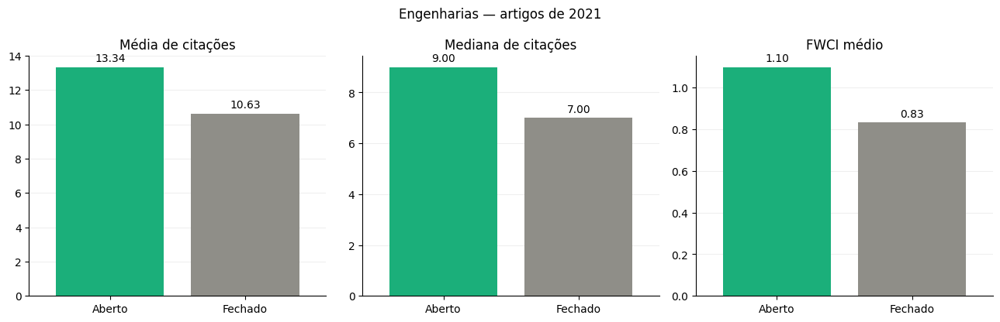

In [ ]:
# @title Resultado — Engenharias: aberto versus fechado
rotulos_eng = {
    "artigos": "Artigos (n)",
    "periodicos": "Periódicos (n)",
    "n_citacoes": "Com citações informadas (n)",
    "media_citacoes": "Média de citações",
    "mediana_citacoes": "Mediana de citações",
    "n_fwci": "Com FWCI (n)",
    "fwci_medio": "FWCI médio",
    "cobertura_fwci": "Cobertura FWCI (%)"
}

tabela_eng = resumo_eng.rename(columns=rotulos_eng)
tabela_eng.index.name = "Acesso"

print(f"ENGENHARIAS — artigos de {ANO_ENG}")
display(tabela_eng.round(2).fillna("—"))

metricas_eng = [
    ("Média de citações", "media_citacoes"),
    ("Mediana de citações", "mediana_citacoes"),
    ("FWCI médio", "fwci_medio")
]

comparacoes_eng = []
for nome, campo in metricas_eng:
    aberto = resumo_eng.loc["Aberto", campo]
    fechado = resumo_eng.loc["Fechado", campo]

    comparacoes_eng.append({
        "Indicador": nome,
        "Aberto": aberto,
        "Fechado": fechado,
        "Diferença (aberto − fechado)": aberto - fechado,
        "Diferença relativa (%)": (
            100 * (aberto / fechado - 1)
            if pd.notna(fechado) and fechado > 0 else np.nan
        )
    })

display(pd.DataFrame(comparacoes_eng).round(2).fillna("—"))

fig, eixos = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (nome, campo) in zip(eixos, metricas_eng):
    valores = resumo_eng[campo].to_numpy(dtype=float)
    ax.bar(["Aberto", "Fechado"], valores, color=["#1baf7a", "#8f8e88"])

    for posicao, valor in enumerate(valores):
        if np.isfinite(valor):
            ax.annotate(
                f"{valor:.2f}", (posicao, valor),
                xytext=(0, 5), textcoords="offset points", ha="center"
            )
        else:
            ax.text(posicao, 0, "Sem dados", ha="center", va="bottom")

    ax.set_title(nome)
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(bottom=0)
    ax.margins(y=0.20)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

fig.suptitle(f"Engenharias — artigos de {ANO_ENG}")
fig.tight_layout()
display(fig)
plt.close(fig)


**Exemplo de prompt para gerar uma nova célula com uma LLM**

Atue como especialista em Python, Google Colab e análise de dados do OpenAlex. Gere **uma única célula de código**, pronta para inserir no notebook, seguindo estas especificações:

- **Objetivo:** analisar a quantidade de preprints e datasets da Unicamp por ano.
- **Recorte:** trabalhos com pelo menos um autor com afiliação à Universidade Estadual de Campinas — Unicamp, publicados entre 2021 e 2025.
- **Entradas:** permitir que o usuário informe o identificador da instituição e os anos inicial e final, usando `I181391015`, `2021` e `2025` como valores padrão.
- **Contexto do notebook:** já existe um cliente autenticado chamado `cliente`, com o método `cliente.get(endpoint, params)`. Reutilize esse cliente.
- **Consulta:** utilizar o endpoint `works`, filtrando por `authorships.institutions.lineage` e `publication_year`. Consultar separadamente os tipos `type:preprint` e `type:dataset` para cada ano.
- **Contagem:** obter os totais pelo campo `meta.count`, solicitando apenas um registro por consulta. Não baixar todos os trabalhos.
- **Resultado:** exibir uma tabela com ano, quantidade de preprints, quantidade de datasets e total combinado; apresentar também um gráfico de barras agrupadas comparando os dois tipos por ano.
- **Resumo:** mostrar os totais de preprints e datasets no período.
- **Validação:** verificar se o cliente existe e se o intervalo de anos é válido. Informar falhas de consulta sem convertê-las em contagens iguais a zero.
- **Apresentação:** utilizar títulos e comentários em português e identificar a instituição e o período nos resultados.

Retorne somente um bloco de código Python, começando com `# @title Preprints e datasets da Unicamp — 2021–2025`, sem explicações fora do código.

**Para praticar:** altere a instituição, o período ou os tipos de documentos e avalie se a célula gerada corresponde ao recorte definido.




Iniciando coleta para a instituição: I181391015 | Período: 2021 a 2025...

PRODUÇÃO DE PREPRINTS E DATASETS
Instituição (Lineage ID): I181391015 | Período: 2021 - 2025


,Ano,Preprints,Datasets,Total Combinado
0,2021,458,110,568
1,2022,404,154,558
2,2023,529,93,622
3,2024,598,11,609
4,2025,465,200,665


--------------------------------------------------------------------------------
RESUMO DO PERÍODO (2021–2025):
• Total de Preprints:       2.454
• Total de Datasets:        568
• Total Combinado no Período: 3.022



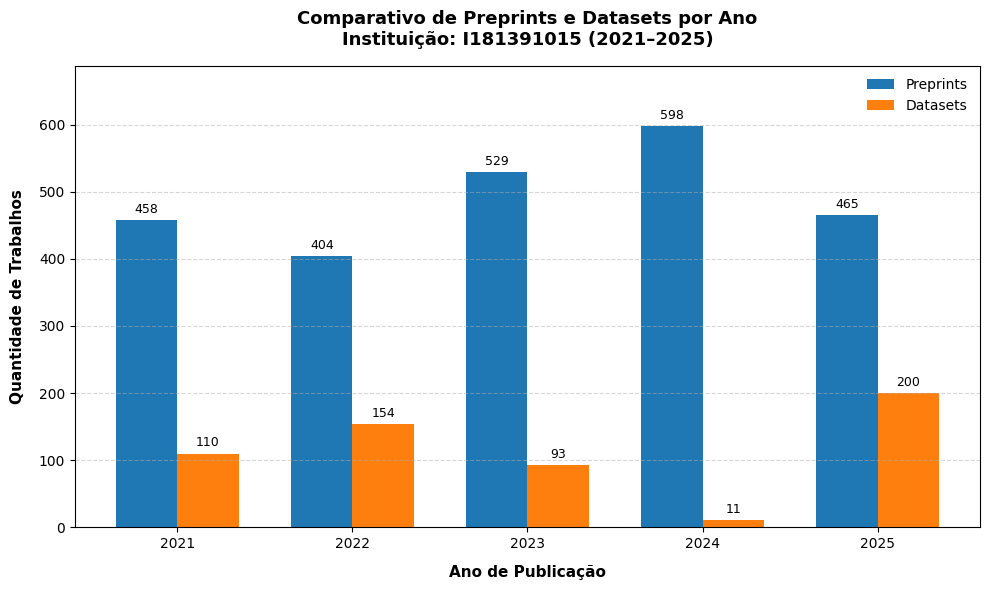

In [ ]:
# @title Preprints e datasets da Unicamp — 2021–2025

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PARÂMETROS DE ENTRADA (Google Colab Forms)
# ==============================================================================
id_instituicao = "I181391015"  # @param {type:"string"}
ano_inicial = 2021  # @param {type:"integer"}
ano_final = 2025  # @param {type:"integer"}

# ==============================================================================
# 2. VALIDAÇÃO DE CONTEXTO E PARÂMETROS
# ==============================================================================
if "cliente" not in globals() or not hasattr(cliente, "get"):
    raise RuntimeError(
        "Erro de Contexto: O cliente autenticado 'cliente' com o método 'get(endpoint, params)' "
        "não foi localizado no ambiente. Execute a célula de configuração do cliente previamente."
    )

if ano_inicial > ano_final:
    raise ValueError(
        f"Intervalo de anos inválido: ano_inicial ({ano_inicial}) não pode ser maior que ano_final ({ano_final})."
    )

# ==============================================================================
# 3. FUNÇÃO AUXILIAR DE CONSULTA AO OPENALEX
# ==============================================================================
def obter_contagem(filtros: list[str]) -> int:
    """Consulta o endpoint 'works' solicitando 1 item por página para extrair meta.count."""
    params = {
        "filter": ",".join(filtros),
        "per_page": 1,
    }
    try:
        resposta = cliente.get("works", params=params)
    except Exception as e:
        raise RuntimeError(f"Falha na requisição ao endpoint 'works' com filtros {filtros}: {e}")

    dados = resposta.json() if hasattr(resposta, "json") and callable(resposta.json) else resposta

    if not isinstance(dados, dict) or "meta" not in dados or "count" not in dados["meta"]:
        raise ValueError(
            f"Estrutura inesperada na resposta da API OpenAlex para os filtros {filtros}: {dados}"
        )

    return dados["meta"]["count"]

# ==============================================================================
# 4. COLETA E PROCESSAMENTO DOS DADOS
# ==============================================================================
inst_id = id_instituicao.strip()
anos = list(range(ano_inicial, ano_final + 1))
registros = []

print(f"Iniciando coleta para a instituição: {inst_id} | Período: {ano_inicial} a {ano_final}...")

for ano in anos:
    filtro_base = [
        f"authorships.institutions.lineage:{inst_id}",
        f"publication_year:{ano}"
    ]

    qtd_preprints = obter_contagem(filtro_base + ["type:preprint"])
    qtd_datasets = obter_contagem(filtro_base + ["type:dataset"])
    total_ano = qtd_preprints + qtd_datasets

    registros.append({
        "Ano": ano,
        "Preprints": qtd_preprints,
        "Datasets": qtd_datasets,
        "Total Combinado": total_ano,
    })

df_resultado = pd.DataFrame(registros)

# ==============================================================================
# 5. APRESENTAÇÃO DOS RESULTADOS (TABELA E RESUMO)
# ==============================================================================
total_preprints_periodo = df_resultado["Preprints"].sum()
total_datasets_periodo = df_resultado["Datasets"].sum()
total_geral_periodo = df_resultado["Total Combinado"].sum()

print("\n" + "=" * 80)
print("PRODUÇÃO DE PREPRINTS E DATASETS")
print(f"Instituição (Lineage ID): {inst_id} | Período: {ano_inicial} - {ano_final}")
print("=" * 80)

try:
    from IPython.display import display
    display(df_resultado)
except ImportError:
    print(df_resultado.to_string(index=False))

print("-" * 80)
print(f"RESUMO DO PERÍODO ({ano_inicial}–{ano_final}):")
print(f"• Total de Preprints:       {total_preprints_periodo:,}".replace(",", "."))
print(f"• Total de Datasets:        {total_datasets_periodo:,}".replace(",", "."))
print(f"• Total Combinado no Período: {total_geral_periodo:,}".replace(",", "."))
print("=" * 80 + "\n")

# ==============================================================================
# 6. GERAÇÃO DO GRÁFICO DE BARRAS AGRUPADAS
# ==============================================================================
x = np.arange(len(anos))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras_preprints = ax.bar(
    x - largura / 2, df_resultado["Preprints"], largura, label="Preprints", color="#1f77b4"
)
barras_datasets = ax.bar(
    x + largura / 2, df_resultado["Datasets"], largura, label="Datasets", color="#ff7f0e"
)

ax.set_xlabel("Ano de Publicação", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel("Quantidade de Trabalhos", fontsize=11, fontweight="bold", labelpad=10)
ax.set_title(
    f"Comparativo de Preprints e Datasets por Ano\nInstituição: {inst_id} ({ano_inicial}–{ano_final})",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xticks(x)
ax.set_xticklabels(anos)
ax.legend(frameon=True, facecolor="white", edgecolor="none")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Rótulos de dados sobre as barras
ax.bar_label(barras_preprints, padding=3, fmt="%d", fontsize=9)
ax.bar_label(barras_datasets, padding=3, fmt="%d", fontsize=9)

limite_superior = max(df_resultado["Preprints"].max(), df_resultado["Datasets"].max(), 1)
ax.set_ylim(0, limite_superior * 1.15)

plt.tight_layout()
plt.show()